<h1>Categorical Shifts</h1>

Temporary file, intended for inclusion in the main.ipynb


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from preprocessor import Preprocessor
from config_local import config
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import plotly.graph_objects as go
import plotly.io as pio

In [3]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

articles,categories,links = preprocessor.load_data()

Preprocess categories

In [4]:
# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

In [5]:
# Extract the category (final element) and create the article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

# Create dataframe using the mapped article caterogies
cat_df = pd.DataFrame(
    {"category": article_cats}
).value_counts().reset_index(name="count").sort_values("count", ascending=False)

# Remove missing articles
cat_df_clean = cat_df[cat_df["category"] != "Unknown"].reset_index(drop=True)

<h3>Categories</h3>


There are 43379 articles with unknown categories (~7.5%)

In [6]:
# Count missing categories
mis_count = cat_df.loc[cat_df["category"] == "Unknown", "count"].sum()
mis_perc = mis_count / len(article_cats) 

# Prints
print(f"'No. of unknown categories: {mis_count}")
print(f"'Unknown' categories account for approximately {mis_perc:.2%} of all entries.")

'No. of unknown categories: 43379
'Unknown' categories account for approximately 9.11% of all entries.


Global category distribution

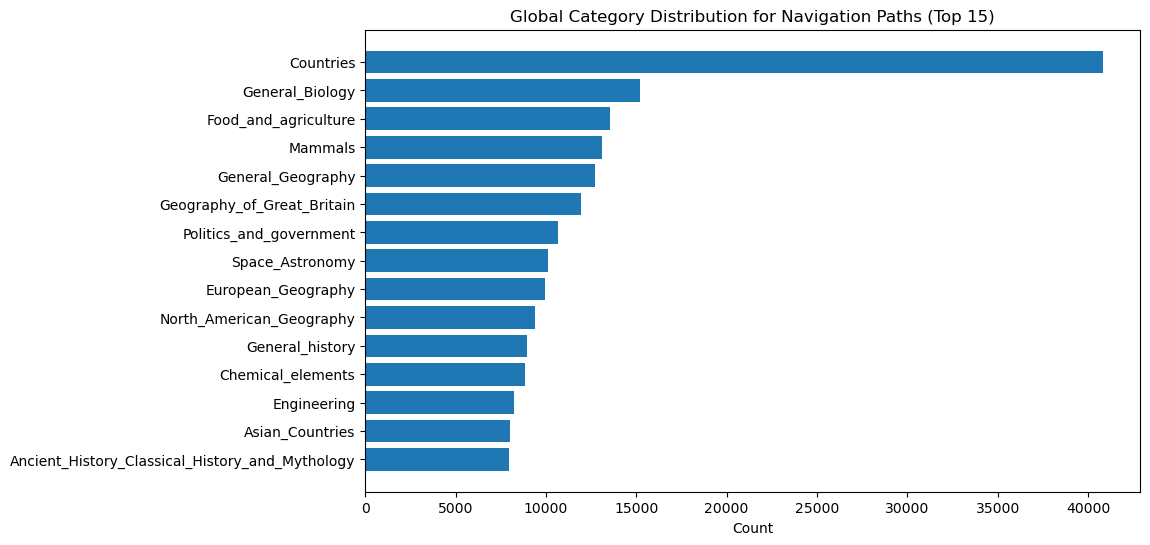

In [7]:
# Plot the 15 top categories while excluding missing categories
plt.figure(figsize=(10, 6))
plt.barh(cat_df_clean.head(15)["category"], cat_df_clean.head(15)["count"])
plt.xlabel("Count")
plt.title("Global Category Distribution for Navigation Paths (Top 15)")
plt.gca().invert_yaxis()
plt.show()

Most frequent category shifts along the navigation paths

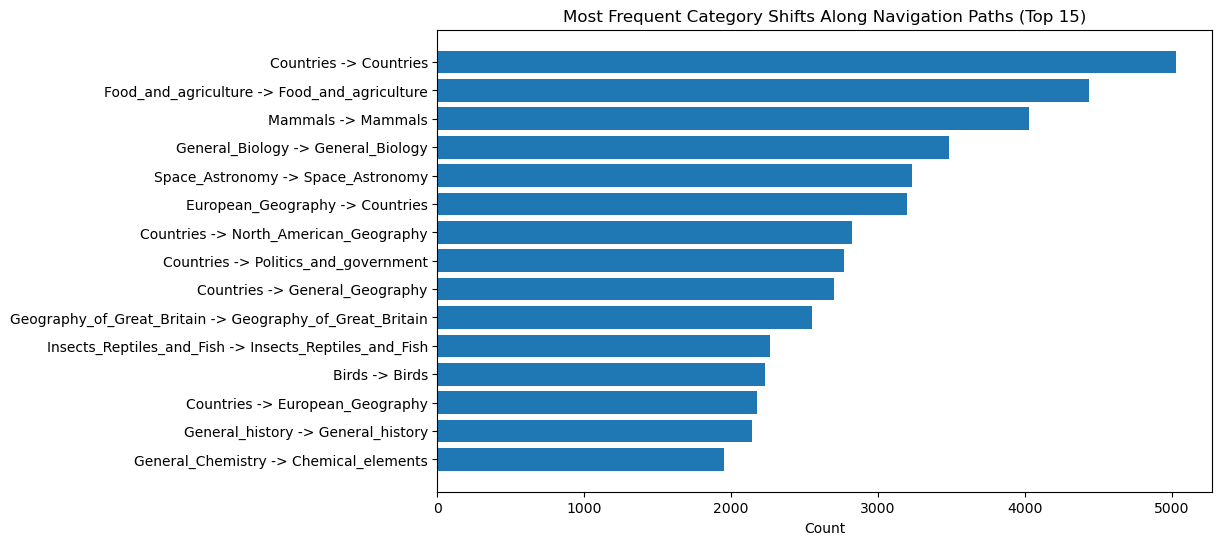

In [8]:
# Extract all consecitive category pairs (A → B) from the navigatins path
category_nav = [
    (article_cats[i], article_cats[i + 1])
    for i in range(len(article_cats) - 1)
    if article_cats[i] in cat_df_clean["category"].values
    and article_cats[i + 1] in cat_df_clean["category"].values
]


# Count pairwise category occurences
cat_shift_counts = Counter(category_nav)

# Convert to df
cat_shift_df = pd.DataFrame(cat_shift_counts.items(), columns=["cat_move", "count"])
# Split cat_move col
cat_shift_df[["from_cat", "to_cat"]] = pd.DataFrame(cat_shift_df["cat_move"].tolist(), index=cat_shift_df.index)
# Drop cat_move col
cat_shift_df = cat_shift_df.drop(columns="cat_move").sort_values("count", ascending=False).reset_index(drop=True)

# Plot the most frequent categorical shifts
cat_shift_df_filter = cat_shift_df.head(15)
plt.figure(figsize=(10, 6))
plt.barh(cat_shift_df_filter["from_cat"] + " -> " + cat_shift_df_filter["to_cat"], cat_shift_df_filter["count"])
plt.xlabel("Count")
plt.title("Most Frequent Category Shifts Along Navigation Paths (Top 15)")
plt.gca().invert_yaxis()
plt.show()


Visualize categorical shifts for finished paths (Interactive only inside notebook: To keep use GitHub Pages, etc.)

In [10]:
# Define start and end category
start_cat, end_cat = "Countries", "Politics_and_government"

# Buold the categorcal transitions along the navigation path for finished paths
category_pairs = [
    # Category pairs encoding
    (f"{a}_{i}", f"{b}_{i+1}")
    # Ireate finished paths
    for cats in article_cats_finished  
    # Valid paths filter
    if len(cats) > 2 and cats[0] == start_cat and cats[-1] == end_cat 
    # Pairwise categories
    for i, (a, b) in enumerate(zip(cats[:-1], cats[1:]))  
    # Include or exclude missing categories (including chosen here to not loose granularity)
    #if a != "Unknown" and b != "Unknown"   
]

# Create df of category frequencies along navigation paths from the pairs
cat_shift_df_pairs = pd.DataFrame(Counter(category_pairs).items(), columns=["cat_move", "count"])
# Split cat_move col
cat_shift_df_pairs[["cat_from", "cat_to"]] = pd.DataFrame(cat_shift_df_pairs["cat_move"].tolist(), index=cat_shift_df_pairs.index)
# Drop cat_move col
cat_shift_df_pairs.drop(columns="cat_move", inplace=True)


# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
# Render method
pio.renderers.default = "notebook_connected"

# Extract unique category nodes 
nodes = pd.unique(cat_shift_df_pairs[["cat_from", "cat_to"]].values.ravel())
# remove positional suffix (e.g. country_1)
node_labels = [n.rsplit("_", 1)[0] for n in nodes]
# Define node indices
node_indices = {n: i for i, n in enumerate(nodes)}

# Build diagram
fig = go.Figure(go.Sankey(
    # Nodes
    node=dict(label=node_labels, 
              pad=22, 
              thickness=16
             ),
    # Links
    link=dict(
        source=[node_indices[a] for a in cat_shift_df_pairs["cat_from"]],
        target=[node_indices[b] for b in cat_shift_df_pairs["cat_to"]],
        value=cat_shift_df_pairs["count"].tolist(),
    )
))

# Layout
fig.update_layout(
    title_text=f"Categorical drift from '{start_cat}' -> '{end_cat}'",
    height=700,
    width=1180,
)

# Plot
fig.write_image("cat_shift_plot.png")  # Save as static image
fig.show() # Interactive plot
